In [ ]:
! rm -rf /content/*

In [ ]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.5/104.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: fonttools
    Found existing installation: fonttools 4.58.1
    Uninstalling fonttools-4.58.1:
      Successfully uninstalled fonttools-4.58.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()  # Upload one or more .zip files

# Extract it to /content
for filename in uploaded.keys():
    if filename.endswith('.zip'):
      with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content")
      print("Extraction complete.")
    else:
        print("mnist.zip was not uploaded.")




Saving mnist.zip to mnist.zip
Extraction complete.


In [ ]:
! python PCA_with_data_augmentation.py

Loading MNIST dataset...
Dataset loaded. Training shape: (60000, 784), Test shape: (10000, 784)
⚙️ Applying image shift data augmentation...
⚙️ Applying PCA (n_components=0.99)...

✅ PCA for fine-tune is saved as pca_fine-tune.joblib

✅ Total components selected: 345

📊 Explained variance per component:
Component   1: 0.0891 (Cumulative: 0.0891)
Component   2: 0.0645 (Cumulative: 0.1537)
Component   3: 0.0556 (Cumulative: 0.2092)
Component   4: 0.0501 (Cumulative: 0.2593)
Component   5: 0.0453 (Cumulative: 0.3046)
Component   6: 0.0415 (Cumulative: 0.3461)
Component   7: 0.0322 (Cumulative: 0.3783)
Component   8: 0.0299 (Cumulative: 0.4083)
Component   9: 0.0279 (Cumulative: 0.4361)
Component  10: 0.0237 (Cumulative: 0.4598)
Component  11: 0.0223 (Cumulative: 0.4821)
Component  12: 0.0203 (Cumulative: 0.5024)
Component  13: 0.0179 (Cumulative: 0.5203)
Component  14: 0.0174 (Cumulative: 0.5377)
Component  15: 0.0155 (Cumulative: 0.5532)
Component  16: 0.0147 (Cumulative: 0.5679)
Compone

In [ ]:
# Download PCA joblib for Gradio app

from google.colab import files

filename = "pca_fine_tune_0.99.joblib"
files.download(f"/content/{filename}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
! python main.py

In [ ]:
# Download all PNG and Joblib files

import os
from google.colab import files

# Specify the folder
folder_path = '/content'

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.png') or file_name.endswith('.joblib'):
        file_path = os.path.join(folder_path, file_name)
        files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🌐 Downloading PCA-reduced MNIST data from Google Drive...
📦 Loading PCA-reduced MNIST data from file...
✅ Loaded PCA data. Training shape: (60000, 154), Test shape: (60000,)
✅ Loaded PCA data. Testing shape: (10000, 154), Test shape: (10000,)
Making Predictions and Evaluate
Performance Metrics on Test Set.......:
  Accuracy: 0.9174
  Confusion Matrix:
 [[ 938    0    2    4    0   16    8    4    6    2]
 [   0 1104    3    5    1    6    3    1   12    0]
 [   2    3  930   20    5    8   11    8   41    4]
 [   5    0   21  914    2   26    1   13   20    8]
 [   1    0    7    4  903    3    3    3   18   40]
 [   7    2    1   29   11  782   14    3   35    8]
 [   6    2   12    3    8   24  888    2   13    0]
 [   0    2   22    8   10    4    0  954    4   24]
 [   5    3    9   23    7   41    9    4  862   11]
 [   2    4    2   12   32   15    0   24   19  899]]
  Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96

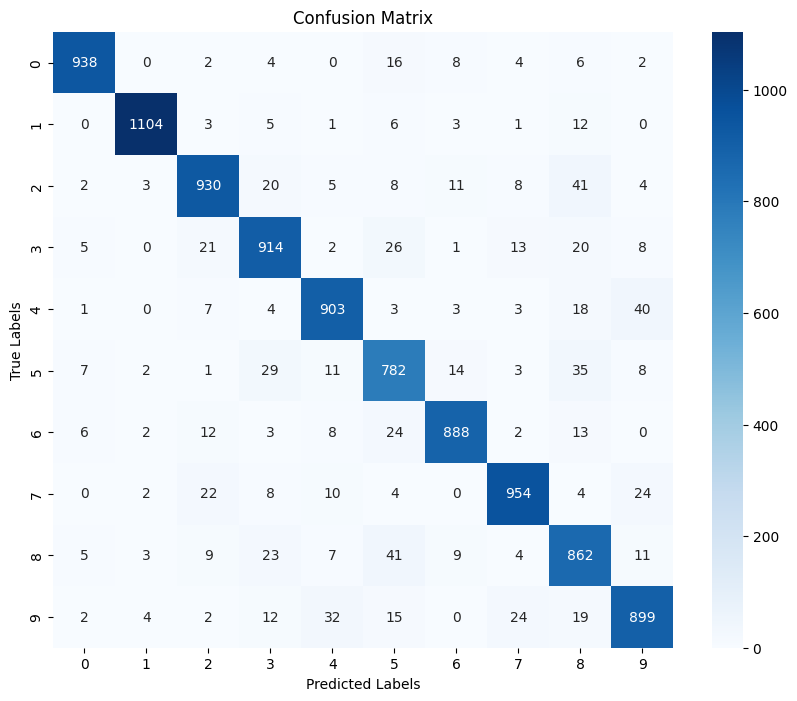

In [ ]:
from load_split_data import load_pca_applied_data
from model_predictions import make_predictions_analyze_fine_tuned_model_on_test_data
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Google Drive file ID from the shareable link
file_id = "1jLwwYnD6CTPTGdu1Bub_04Co5ISO3dQH"
output_path = "/content/mnist_pca_0.95_no_augmented_data.npz"

X_train, X_test, y_train, y_test = load_pca_applied_data(file_id, output_path)


sdf_clf = joblib.load("best_sgd_ovr_train_model.joblib")

scaler = joblib.load("scaler_train.joblib")
X_test_scaled = scaler.fit_transform(X_test)

# Make Predictions and Evaluate
print("Making Predictions and Evaluate")
make_predictions_analyze_fine_tuned_model_on_test_data(
    sdf_clf, X_test_scaled, y_test, type="predict"
)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best hyperparameters found by GridSearchCV:
{'max_depth': 100, 'n_estimators': 50}
Best model saved to 'best_fine_tune_random_forest.joblib'


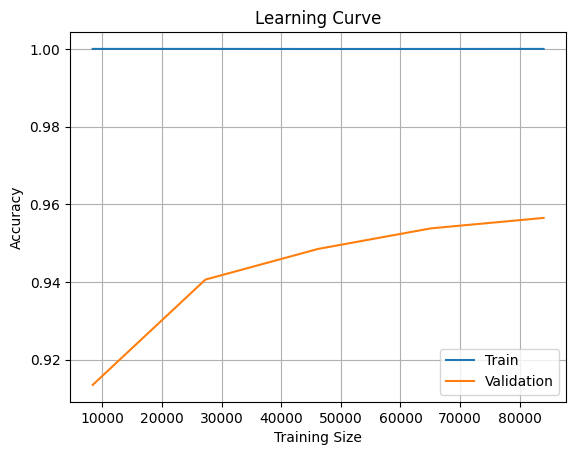

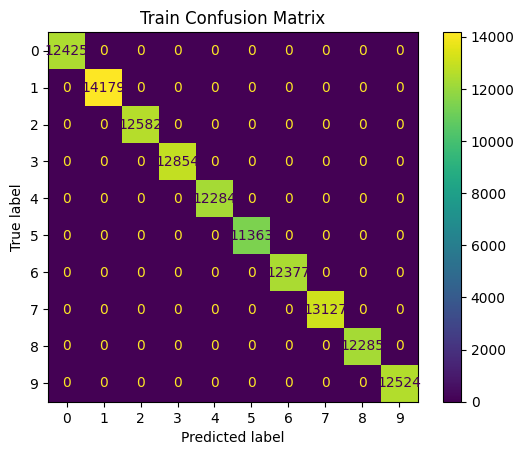

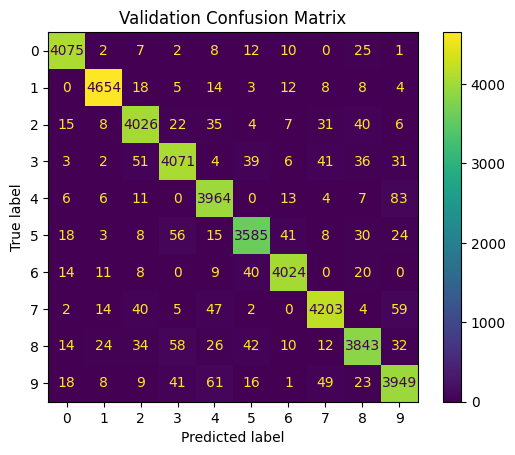

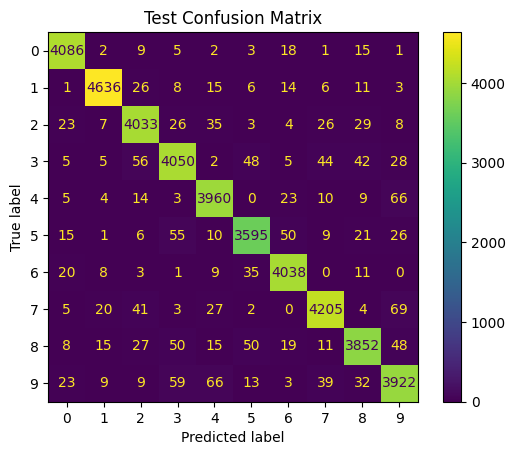

Training report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     12425
           1       1.00      1.00      1.00     14179
           2       1.00      1.00      1.00     12582
           3       1.00      1.00      1.00     12854
           4       1.00      1.00      1.00     12284
           5       1.00      1.00      1.00     11363
           6       1.00      1.00      1.00     12377
           7       1.00      1.00      1.00     13127
           8       1.00      1.00      1.00     12285
           9       1.00      1.00      1.00     12524

    accuracy                           1.00    126000
   macro avg       1.00      1.00      1.00    126000
weighted avg       1.00      1.00      1.00    126000

Validation report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4142
           1       0.98      0.98      0.98      4726
           2       0.96      0.96      0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.ndimage import shift
import joblib

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(np.uint8)
X = X.values if hasattr(X, "values") else X  # For some pandas versions

# Reshape to 28x28 for shifting
X_images = X.reshape(-1, 28, 28)

# Augment by shifting left and right
X_left = np.array([shift(img, shift=[0, -5], cval=0) for img in X_images])
X_right = np.array([shift(img, shift=[0, 5], cval=0) for img in X_images])

# Stack and flatten
X_aug = np.concatenate([X_images, X_left, X_right])
y_aug = np.concatenate([y, y, y])
X_aug_flat = X_aug.reshape(X_aug.shape[0], -1)

# Stratified split: train 60%, val 20%, test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X_aug_flat, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# GridSearchCV for Random Forest
param_grid = {"n_estimators": [30, 40, 50], "max_depth": [100, 150, 200]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", verbose=1)
grid = grid.fit(X_train, y_train)

# Print best hyperparameters
print("Best hyperparameters found by GridSearchCV:")
print(grid.best_params_)

# Get the best estimator from GridSearchCV
grid = grid.best_estimator_  # best model

# Save the best model to a file
joblib.dump(grid, f"best_fine_tune_random_forest.joblib")
print(f"Best model saved to 'best_fine_tune_random_forest.joblib'")
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    grid, X_train, y_train, cv=3, scoring="accuracy"
)
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"random_forest_learning_curve.png")

# Confusion Matrices
def show_confusion(title, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()
    return cm


y_val_pred = grid.predict(X_val)
y_test_pred = grid.predict(X_test)


val_cm = show_confusion("Validation Confusion Matrix", y_val, y_val_pred)
test_cm = show_confusion("Test Confusion Matrix", y_test, y_test_pred)

cr = classification_report(y_val, y_val_pred)
print("Validation report:\n", cr)

cr = classification_report(y_test, y_test_pred)
print("Test report:\n", cr)


# Print Matrices
print("Validation CM:\n", val_cm)
print("Test CM:\n", test_cm)

import zipfile
import os
from google.colab import files

# Define the zip filename
zip_filename = "images_and_models.zip"

# Create a zip file
with zipfile.ZipFile(zip_filename, "w") as zipf:
    for root, _, files_list in os.walk("/content/"):
        for file in files_list:
            if file.endswith(".png") or file.endswith(".joblib"):
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, "/content/")  # relative path inside zip
                zipf.write(file_path, arcname)

# Trigger download
files.download(zip_filename)



Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters found by GridSearchCV:
{'alpha': 0.0001, 'early_stopping': True, 'loss': 'log_loss', 'max_iter': 150, 'penalty': 'l2', 'tol': 0.001}
Best model saved to 'best_fine_tune_sgd.joblib'


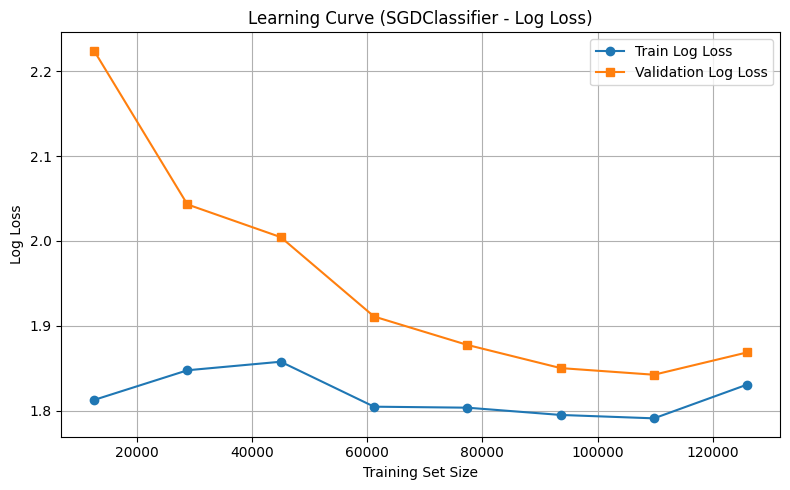

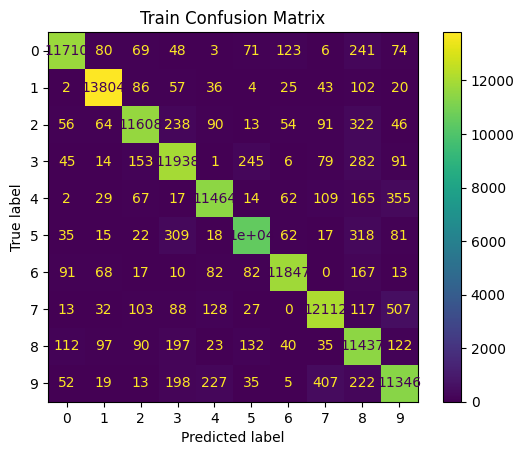

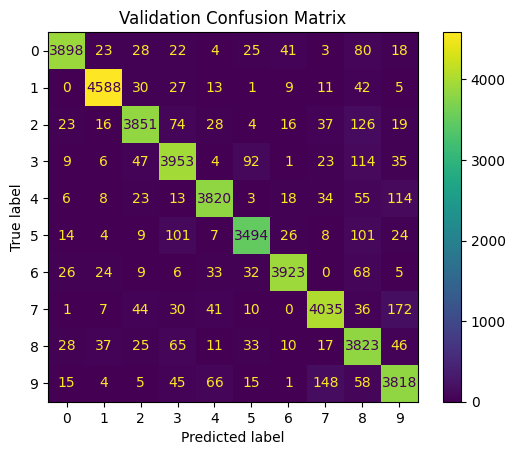

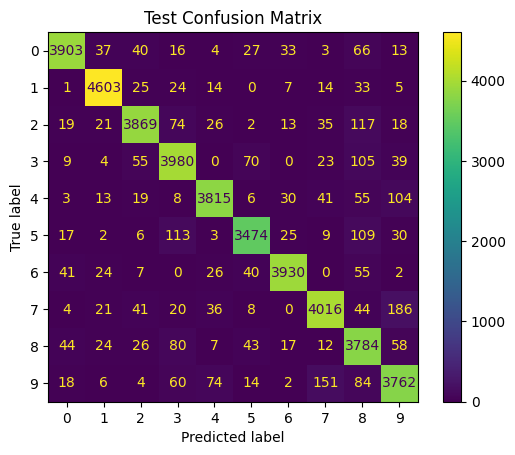

Training report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95     12425
           1       0.97      0.97      0.97     14179
           2       0.95      0.92      0.94     12582
           3       0.91      0.93      0.92     12854
           4       0.95      0.93      0.94     12284
           5       0.94      0.92      0.93     11363
           6       0.97      0.96      0.96     12377
           7       0.94      0.92      0.93     13127
           8       0.86      0.93      0.89     12285
           9       0.90      0.91      0.90     12524

    accuracy                           0.93    126000
   macro avg       0.94      0.93      0.93    126000
weighted avg       0.94      0.93      0.93    126000

Validation report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96      4142
           1       0.97      0.97      0.97      4726
           2       0.95      0.92      0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import shift
import joblib
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.metrics import log_loss, hinge_loss
from sklearn.base import clone

from skimage.feature import hog

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

# Load MNIST (no augmentation)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(np.uint8)
X = X.values if hasattr(X, "values") else X
X_images = X.reshape(-1, 28, 28)

# Augment by shifting left and right
X_left = np.array([shift(img, shift=[0, -5], cval=0) for img in X_images])
X_right = np.array([shift(img, shift=[0, 5], cval=0) for img in X_images])

# Stack and flatten
X_aug = np.concatenate([X_images, X_left, X_right])
y_aug = np.concatenate([y, y, y])
X_aug_flat = X_aug.reshape(X_aug.shape[0], -1)

# 1. Define zoning feature extractor
def extract_zoning_features(img, zones=(4, 4)):
    h, w = img.shape
    zh, zw = zones
    zone_features = []
    for i in range(zh):
        for j in range(zw):
            block = img[i*h//zh:(i+1)*h//zh, j*w//zw:(j+1)*w//zw]
            zone_features.append(block.mean())
    return zone_features



# 2. Compute HOG + Zoning for all augmented images
hog_features = []
zoning_features = []

for img in X_aug:
    hog_feat = hog(img, pixels_per_cell=(7, 7), cells_per_block=(2, 2), feature_vector=True)
    zone_feat = extract_zoning_features(img)
    hog_features.append(hog_feat)
    zoning_features.append(zone_feat)

hog_features = np.array(hog_features)
zoning_features = np.array(zoning_features)

# 3. Concatenate both feature sets
X_final = np.hstack([hog_features, zoning_features])


# 4. Scale final feature matrix
scaler = StandardScaler()
X_final = scaler.fit_transform(X_final)

# 5. Split train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


# GridSearchCV for SGDClassifier
param_grid = {
    'loss': ['hinge', 'log_loss'],
    'alpha': [1e-4, 1e-3],
    'penalty': ['l2'],
    'max_iter': [150, 250, 350, 450, 550],
    'tol': [1e-3],
    'early_stopping' : [True]
}

sgd = SGDClassifier(random_state=42)
grid = GridSearchCV(sgd, param_grid, cv=3, scoring="accuracy", verbose=1)
grid = grid.fit(X_train, y_train)

# Print best hyperparameters
print("Best hyperparameters found by GridSearchCV:")
print(grid.best_params_)

# Get the best estimator
grid = grid.best_estimator_

# Save the best model to a file
joblib.dump(grid, f"best_fine_tune_sgd.joblib")
print(f"Best model saved to 'best_fine_tune_sgd.joblib'")


# Training sizes: 10% to 100%
train_sizes = np.linspace(0.1, 1.0, 8)
train_losses = []
val_losses = []

final_loss = grid.get_params().get('loss')

for frac in train_sizes:
    size = int(frac * len(X_train))
    X_sub = X_train[:size]
    y_sub = y_train[:size]

    model = clone(grid)
    model.fit(X_sub, y_sub)

    if final_loss == 'log_loss':
        # Predict probabilities
        y_sub_proba = model.predict_proba(X_sub)
        y_val_proba = model.predict_proba(X_val)

        # Compute log loss
        train_loss = log_loss(y_sub, y_sub_proba)
        val_loss = log_loss(y_val, y_val_proba)
        loss_name = "Log Loss"

    elif final_loss == 'hinge':
        # Predict margin scores
        y_sub_score = model.decision_function(X_sub)
        y_val_score = model.decision_function(X_val)

        # Compute hinge loss
        train_loss = hinge_loss(y_sub, y_sub_score)
        val_loss = hinge_loss(y_val, y_val_score)
        loss_name = "Hinge Loss"

    else:
        raise ValueError(f"Loss '{final_loss}' is not supported in this dynamic plot.")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes * len(X_train), train_losses, label=f"Train {loss_name}", marker='o')
plt.plot(train_sizes * len(X_train), val_losses, label=f"Validation {loss_name}", marker='s')
plt.title(f"Learning Curve (SGDClassifier - {loss_name})")
plt.xlabel("Training Set Size")
plt.ylabel(loss_name)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"sgd_final_model_learning_curve_{final_loss}.png")
plt.show()


# Confusion Matrices
def show_confusion(title, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()
    return cm

y_train_pred = grid.predict(X_train)
y_val_pred = grid.predict(X_val)
y_test_pred = grid.predict(X_test)

train_cm = show_confusion("Train Confusion Matrix", y_train, y_train_pred)
val_cm = show_confusion("Validation Confusion Matrix", y_val, y_val_pred)
test_cm = show_confusion("Test Confusion Matrix", y_test, y_test_pred)

cr = classification_report(y_train, y_train_pred)
print("Training report:\n", cr)

cr = classification_report(y_val, y_val_pred)
print("Validation report:\n", cr)

cr = classification_report(y_test, y_test_pred)
print("Test report:\n", cr)

# Print Matrices
print("Train CM:\n", train_cm)
print("Validation CM:\n", val_cm)
print("Test CM:\n", test_cm)

import zipfile
import os
from google.colab import files

# Define the zip filename
zip_filename = "images_and_models.zip"

# Create a zip file
with zipfile.ZipFile(zip_filename, "w") as zipf:
    for root, _, files_list in os.walk("/content/"):
        for file in files_list:
            if file.endswith(".png") or file.endswith(".joblib"):
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, "/content/")
                zipf.write(file_path, arcname)

# Trigger download
files.download(zip_filename)


data loaded.....
Split into train/val/test 60%/20%/20% ..........
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters: {'classifier__alpha': 0.0001, 'classifier__early_stopping': True, 'classifier__loss': 'hinge', 'classifier__max_iter': 150, 'classifier__penalty': 'l2', 'classifier__tol': 0.001}
model saved...............
scaler saved...............
plot learning curve ..........


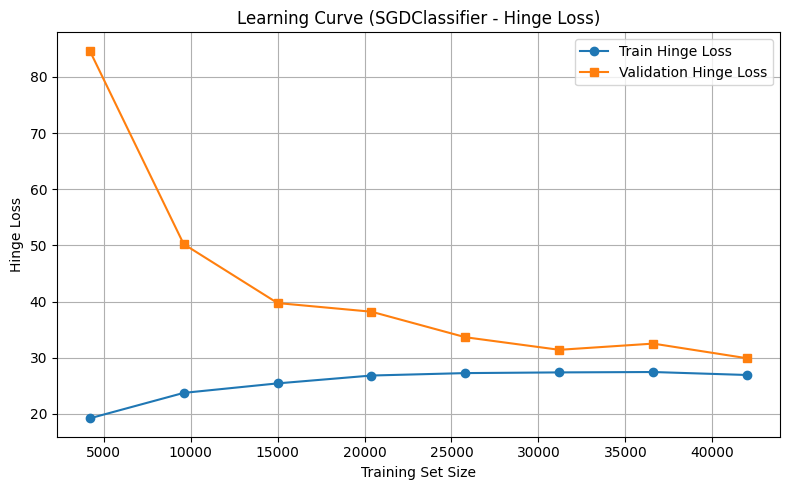

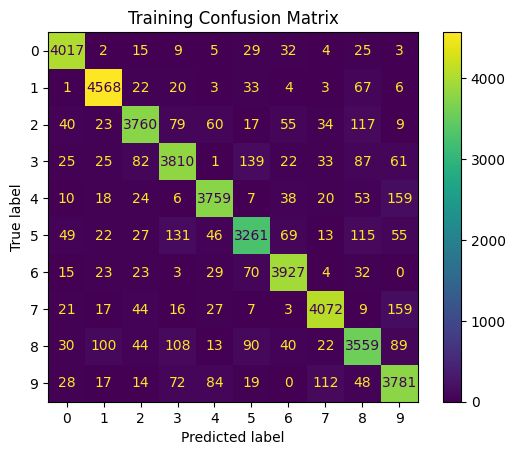

Training Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4141
           1       0.95      0.97      0.96      4727
           2       0.93      0.90      0.91      4194
           3       0.90      0.89      0.89      4285
           4       0.93      0.92      0.93      4094
           5       0.89      0.86      0.87      3788
           6       0.94      0.95      0.94      4126
           7       0.94      0.93      0.94      4375
           8       0.87      0.87      0.87      4095
           9       0.87      0.91      0.89      4175

    accuracy                           0.92     42000
   macro avg       0.92      0.92      0.92     42000
weighted avg       0.92      0.92      0.92     42000



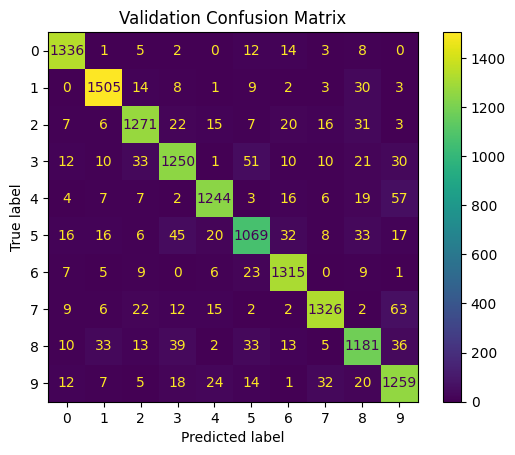

Validation Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.94      0.96      0.95      1575
           2       0.92      0.91      0.91      1398
           3       0.89      0.88      0.88      1428
           4       0.94      0.91      0.92      1365
           5       0.87      0.85      0.86      1262
           6       0.92      0.96      0.94      1375
           7       0.94      0.91      0.92      1459
           8       0.87      0.87      0.87      1365
           9       0.86      0.90      0.88      1392

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



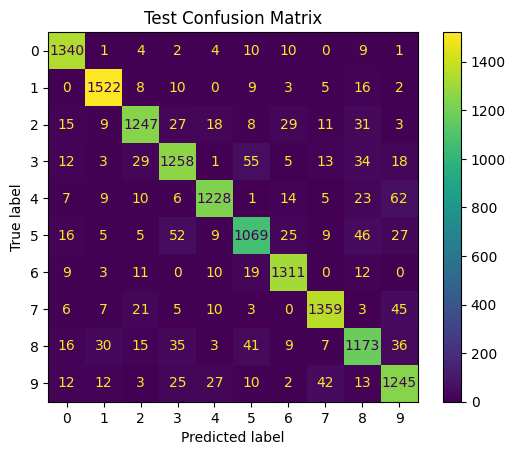

Test Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1381
           1       0.95      0.97      0.96      1575
           2       0.92      0.89      0.91      1398
           3       0.89      0.88      0.88      1428
           4       0.94      0.90      0.92      1365
           5       0.87      0.85      0.86      1263
           6       0.93      0.95      0.94      1375
           7       0.94      0.93      0.93      1459
           8       0.86      0.86      0.86      1365
           9       0.87      0.90      0.88      1391

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, log_loss, hinge_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import gradio as gr
from sklearn.base import BaseEstimator, TransformerMixin, clone

def load_data():
    """Load MNIST dataset and return flattened images with labels"""
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist['data'], mnist['target'].astype(np.uint8)
    return X, y

def create_pipeline():
    """Create sklearn pipeline with preprocessing and classifier"""
    return Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', SGDClassifier(random_state=42))
    ])

def train_and_evaluate(X_train, y_train, X_val, y_val):
    """Train model with hyperparameter tuning and return best model"""
    pipeline = create_pipeline()

    param_grid = {
        'classifier__loss': ['hinge', 'log_loss'],
        'classifier__alpha': [1e-4, 1e-3],
        'classifier__penalty': ['l2'],
        'classifier__max_iter': [150, 250, 350, 450, 550],
        'classifier__tol': [1e-3],
        'classifier__early_stopping': [True]
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", verbose=1)
    grid = grid.fit(X_train, y_train)

    print("Best hyperparameters:", grid.best_params_)
    return grid

def plot_learning_curve(model, X_train, y_train, X_val, y_val):
    """Generate learning curve plot"""
    train_sizes = np.linspace(0.1, 1.0, 8)
    train_losses, val_losses = [], []

    final_loss = model.get_params()['classifier__loss']

    for frac in train_sizes:
        size = int(frac * len(X_train))
        X_sub, y_sub = X_train[:size], y_train[:size]

        model_clone = clone(model)
        model_clone.fit(X_sub, y_sub)

        if final_loss == 'log_loss':
            train_loss = log_loss(y_sub, model_clone.predict_proba(X_sub))
            val_loss = log_loss(y_val, model_clone.predict_proba(X_val))
            loss_name = "Log Loss"
        else:  # hinge loss
            train_loss = hinge_loss(y_sub, model_clone.decision_function(X_sub))
            val_loss = hinge_loss(y_val, model_clone.decision_function(X_val))
            loss_name = "Hinge Loss"

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes * len(X_train), train_losses, 'o-', label=f"Train {loss_name}")
    plt.plot(train_sizes * len(X_train), val_losses, 's-', label=f"Validation {loss_name}")
    plt.title(f"Learning Curve (SGDClassifier - {loss_name})")
    plt.xlabel("Training Set Size")
    plt.ylabel(loss_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"learning_curve_{final_loss}.png")
    plt.show()

def show_confusion_matrix(y_true, y_pred, title):
    """Display confusion matrix with given title"""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()




def main():
    """Main training pipeline"""
    X, y = load_data()
    print("data loaded.....")

    # Split into train/val/test (60%/20%/20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

    print("Split into train/val/test 60%/20%/20% ..........")

    # Train and evaluate model
    grid = train_and_evaluate(X_train, y_train, X_val, y_val)
    model = grid.best_estimator_

    joblib.dump(model, "best_sgd_model.joblib")
    print("model saved...............")

    try:
      scaler = model.named_steps["scaler"]
      joblib.dump(scaler, "scaler.joblib")
      print("scaler saved...............")
    except:
      try:
        scaler = grid.named_steps["scaler"]
        joblib.dump(scaler, "scaler.joblib")
        print("scaler saved...............")
      except:
        pass

    # Generate learning curve
    print("plot learning curve ..........")
    plot_learning_curve(model, X_train, y_train, X_val, y_val)

    # Evaluate on all sets
    for (x, y_true, name) in [
        (X_train, y_train, "Training"),
        (X_val, y_val, "Validation"),
        (X_test, y_test, "Test")
    ]:
        y_pred = model.predict(x)
        show_confusion_matrix(y_true, y_pred, f"{name} Confusion Matrix")
        print(f"{name} Report:\n{classification_report(y_true, y_pred)}")

if __name__ == '__main__':
    main()




Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best hyperparameters found by GridSearchCV:
{'alpha': 0.001, 'early_stopping': True, 'loss': 'hinge', 'max_iter': 150, 'penalty': 'l2', 'tol': 0.001}
Best model saved to 'best_fine_tune_sgd.joblib'
Scaler saved to 'scaler.joblib'


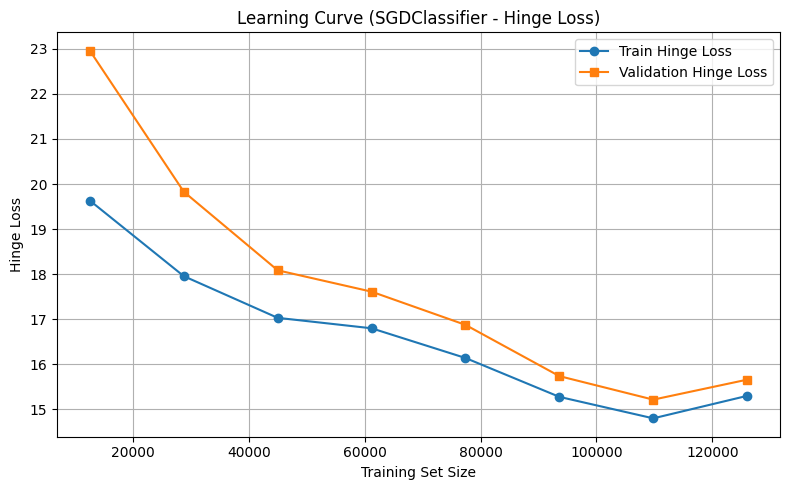

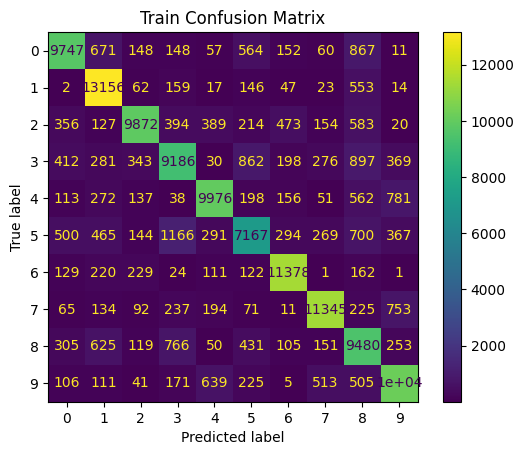

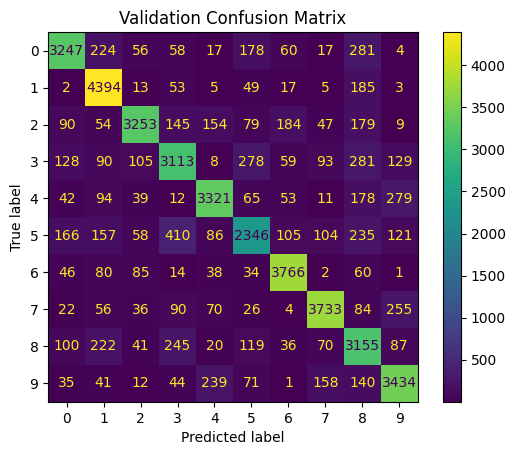

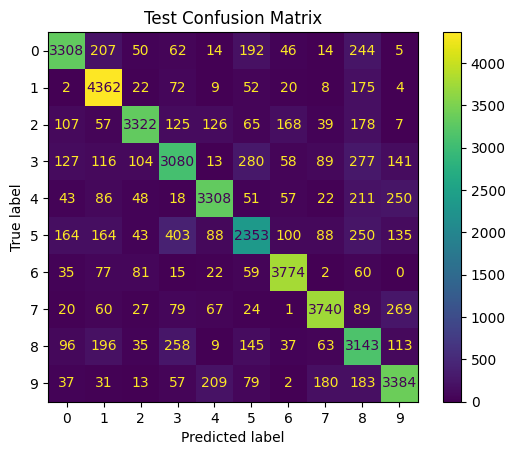

Training report:
               precision    recall  f1-score   support

           0       0.83      0.78      0.81     12425
           1       0.82      0.93      0.87     14179
           2       0.88      0.78      0.83     12582
           3       0.75      0.71      0.73     12854
           4       0.85      0.81      0.83     12284
           5       0.72      0.63      0.67     11363
           6       0.89      0.92      0.90     12377
           7       0.88      0.86      0.87     13127
           8       0.65      0.77      0.71     12285
           9       0.80      0.82      0.81     12524

    accuracy                           0.81    126000
   macro avg       0.81      0.80      0.80    126000
weighted avg       0.81      0.81      0.81    126000

Validation report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81      4142
           1       0.81      0.93      0.87      4726
           2       0.88      0.78      0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from scipy.ndimage import shift
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    hinge_loss,
    log_loss,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.uint8)
X = X.values if hasattr(X, "values") else X  # For some pandas versions

# Reshape to 28x28 for shifting
X_images = X.reshape(-1, 28, 28)

# Augment by shifting left and right
X_left = np.array([shift(img, shift=[0, -5], cval=0) for img in X_images])
X_right = np.array([shift(img, shift=[0, 5], cval=0) for img in X_images])

# Stack and flatten
X_aug = np.concatenate([X_images, X_left, X_right])
y_aug = np.concatenate([y, y, y])
X_aug_flat = X_aug.reshape(X_aug.shape[0], -1)

# Scale features
scaler = StandardScaler()
X_aug_flat = scaler.fit_transform(X_aug_flat)

# Stratified split: train 60%, val 20%, test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X_aug_flat, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# GridSearchCV for SGDClassifier
param_grid = {
    "loss": ["hinge", "log_loss"],
    "alpha": [1e-4, 1e-3],
    "penalty": ["l2"],
    "max_iter": [150, 250, 350, 450, 550],
    "tol": [1e-3],
    "early_stopping": [True],
}

sgd = SGDClassifier(random_state=42)
grid = GridSearchCV(sgd, param_grid, cv=3, scoring="accuracy", verbose=1)
grid = grid.fit(X_train, y_train)

# Print best hyperparameters
print("Best hyperparameters found by GridSearchCV:")
print(grid.best_params_)

# Get the best estimator
grid = grid.best_estimator_

# Save the best model to a file
joblib.dump(grid, f"best_fine_tune_sgd.joblib")
print(f"Best model saved to 'best_fine_tune_sgd.joblib'")

# **Save the scaler**
joblib.dump(scaler, "scaler.joblib")
print("Scaler saved to 'scaler.joblib'")


# Training sizes: 10% to 100%
train_sizes = np.linspace(0.1, 1.0, 8)
train_losses = []
val_losses = []

final_loss = grid.get_params().get("loss")

for frac in train_sizes:
    size = int(frac * len(X_train))
    X_sub = X_train[:size]
    y_sub = y_train[:size]

    model = clone(grid)
    model.fit(X_sub, y_sub)

    if final_loss == "log_loss":
        # Predict probabilities
        y_sub_proba = model.predict_proba(X_sub)
        y_val_proba = model.predict_proba(X_val)

        # Compute log loss
        train_loss = log_loss(y_sub, y_sub_proba)
        val_loss = log_loss(y_val, y_val_proba)
        loss_name = "Log Loss"

    elif final_loss == "hinge":
        # Predict margin scores
        y_sub_score = model.decision_function(X_sub)
        y_val_score = model.decision_function(X_val)

        # Compute hinge loss
        train_loss = hinge_loss(y_sub, y_sub_score)
        val_loss = hinge_loss(y_val, y_val_score)
        loss_name = "Hinge Loss"

    else:
        raise ValueError(f"Loss '{final_loss}' is not supported in this dynamic plot.")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(
    train_sizes * len(X_train), train_losses, label=f"Train {loss_name}", marker="o"
)
plt.plot(
    train_sizes * len(X_train), val_losses, label=f"Validation {loss_name}", marker="s"
)
plt.title(f"Learning Curve (SGDClassifier - {loss_name})")
plt.xlabel("Training Set Size")
plt.ylabel(loss_name)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"sgd_final_model_learning_curve_{final_loss}.png")
plt.show()


# Confusion Matrices
def show_confusion(title, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()
    return cm


y_train_pred = grid.predict(X_train)
y_val_pred = grid.predict(X_val)
y_test_pred = grid.predict(X_test)

train_cm = show_confusion("Train Confusion Matrix", y_train, y_train_pred)
val_cm = show_confusion("Validation Confusion Matrix", y_val, y_val_pred)
test_cm = show_confusion("Test Confusion Matrix", y_test, y_test_pred)

cr = classification_report(y_train, y_train_pred)
print("Training report:\n", cr)

cr = classification_report(y_val, y_val_pred)
print("Validation report:\n", cr)

cr = classification_report(y_test, y_test_pred)
print("Test report:\n", cr)

# Print Matrices
print("Train CM:\n", train_cm)
print("Validation CM:\n", val_cm)
print("Test CM:\n", test_cm)


# Define the zip filename
zip_filename = "images_and_models.zip"

# Create a zip file
with zipfile.ZipFile(zip_filename, "w") as zipf:
    for root, _, files_list in os.walk("/content/"):
        for file in files_list:
            if file.endswith(".png") or file.endswith(".joblib"):
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, "/content/")
                zipf.write(file_path, arcname)

# Trigger download
files.download(zip_filename)


input shape after train test split: (126000, 28, 28)
input shape in GridseachCV: (126000, 28, 28)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
HOG features shape: (84000, 324)
Zoning features shape: (84000, 16)
Combined features shape: (84000, 340)
HOG features shape: (42000, 324)
Zoning features shape: (42000, 16)
Combined features shape: (42000, 340)
HOG features shape: (84000, 324)
Zoning features shape: (84000, 16)
Combined features shape: (84000, 340)
HOG features shape: (42000, 324)
Zoning features shape: (42000, 16)
Combined features shape: (42000, 340)
HOG features shape: (84000, 324)
Zoning features shape: (84000, 16)
Combined features shape: (84000, 340)
HOG features shape: (42000, 324)
Zoning features shape: (42000, 16)
Combined features shape: (42000, 340)
HOG features shape: (84000, 324)
Zoning features shape: (84000, 16)
Combined features shape: (84000, 340)
HOG features shape: (42000, 324)
Zoning features shape: (42000, 16)
Combined features shape: (42000

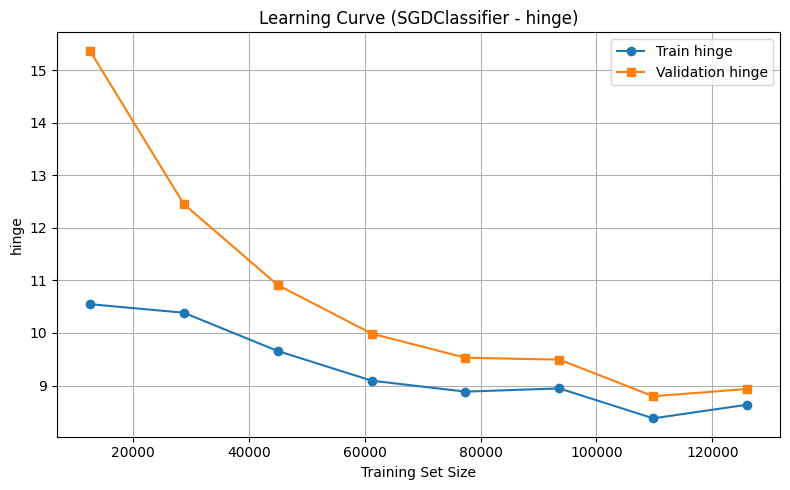

HOG features shape: (126000, 324)
Zoning features shape: (126000, 16)
Combined features shape: (126000, 340)


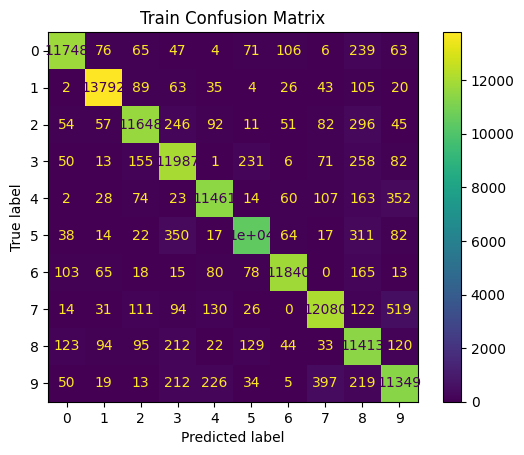

Train classification report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95     12425
           1       0.97      0.97      0.97     14179
           2       0.95      0.93      0.94     12582
           3       0.90      0.93      0.92     12854
           4       0.95      0.93      0.94     12284
           5       0.95      0.92      0.93     11363
           6       0.97      0.96      0.96     12377
           7       0.94      0.92      0.93     13127
           8       0.86      0.93      0.89     12285
           9       0.90      0.91      0.90     12524

    accuracy                           0.93    126000
   macro avg       0.94      0.93      0.93    126000
weighted avg       0.94      0.93      0.93    126000

Train confusion matrix:
 [[11748    76    65    47     4    71   106     6   239    63]
 [    2 13792    89    63    35     4    26    43   105    20]
 [   54    57 11648   246    92    11    51    82   296    4

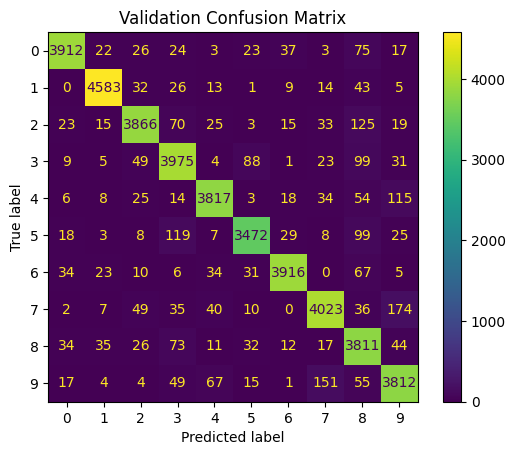

Validation classification report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95      4142
           1       0.97      0.97      0.97      4726
           2       0.94      0.92      0.93      4194
           3       0.91      0.93      0.92      4284
           4       0.95      0.93      0.94      4094
           5       0.94      0.92      0.93      3788
           6       0.97      0.95      0.96      4126
           7       0.93      0.92      0.93      4376
           8       0.85      0.93      0.89      4095
           9       0.90      0.91      0.91      4175

    accuracy                           0.93     42000
   macro avg       0.93      0.93      0.93     42000
weighted avg       0.93      0.93      0.93     42000

Validation confusion matrix:
 [[3912   22   26   24    3   23   37    3   75   17]
 [   0 4583   32   26   13    1    9   14   43    5]
 [  23   15 3866   70   25    3   15   33  125   19]
 [   9    5   49 

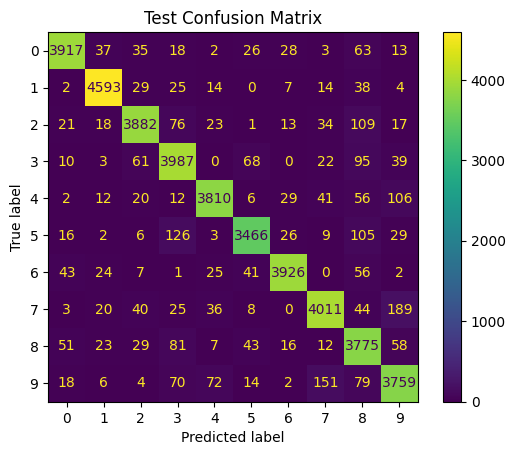

Test classification report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      4142
           1       0.97      0.97      0.97      4726
           2       0.94      0.93      0.93      4194
           3       0.90      0.93      0.92      4285
           4       0.95      0.93      0.94      4094
           5       0.94      0.91      0.93      3788
           6       0.97      0.95      0.96      4125
           7       0.93      0.92      0.92      4376
           8       0.85      0.92      0.89      4095
           9       0.89      0.90      0.90      4175

    accuracy                           0.93     42000
   macro avg       0.93      0.93      0.93     42000
weighted avg       0.93      0.93      0.93     42000

Test confusion matrix:
 [[3917   37   35   18    2   26   28    3   63   13]
 [   2 4593   29   25   14    0    7   14   38    4]
 [  21   18 3882   76   23    1   13   34  109   17]
 [  10    3   61 3987    0   

NameError: name 'files' is not defined

In [1]:
import os
import zipfile
from google.colab import runtime
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, log_loss, hinge_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.ndimage import shift
import joblib
from skimage.feature import hog
import gradio as gr
from sklearn.base import BaseEstimator, TransformerMixin, clone
import gradio as gr
import joblib
import numpy as np
from PIL import Image
from skimage.feature import hog
from skimage.transform import resize



# ---------------------- Custom Transformers ----------------------

class ZoningFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, zones=(4, 4)):
        self.zones = zones

    def extract_zoning_features(self, img):
        h, w = img.shape
        zh, zw = self.zones
        zone_features = []
        for i in range(zh):
            for j in range(zw):
                block = img[i*h//zh:(i+1)*h//zh, j*w//zw:(j+1)*w//zw]
                zone_features.append(block.mean())
        return zone_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.array([self.extract_zoning_features(img) for img in X])


class HOGFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, pixels_per_cell=(7, 7), cells_per_block=(2, 2)):
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.array([
            hog(img, pixels_per_cell=self.pixels_per_cell,
                cells_per_block=self.cells_per_block,
                feature_vector=True)
            for img in X
        ])

class FeatureCombiner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.hog_extractor = HOGFeatureExtractor()
        self.zoning_extractor = ZoningFeatureExtractor()

    def fit(self, X, y=None):
        self.hog_extractor.fit(X)
        self.zoning_extractor.fit(X)
        return self

    def transform(self, X):
        hog_feats = self.hog_extractor.transform(X)
        print("HOG features shape:", hog_feats.shape)

        zoning_feats = self.zoning_extractor.transform(X)
        print("Zoning features shape:", zoning_feats.shape)

        print("Combined features shape:", np.hstack([hog_feats, zoning_feats]).shape)
        return np.hstack([hog_feats, zoning_feats])

# ---------------------- Data Preparation ----------------------

def load_and_augment_mnist():
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist["data"], mnist["target"].astype(np.uint8)
    X = X.values if hasattr(X, "values") else X
    X_images = X.reshape(-1, 28, 28)

    # Augment: shift left and right
    X_left = np.array([shift(img, shift=[0, -5], cval=0) for img in X_images])
    X_right = np.array([shift(img, shift=[0, 5], cval=0) for img in X_images])

    # Combine
    X_aug = np.concatenate([X_images, X_left, X_right])
    y_aug = np.concatenate([y, y, y])

    return X_aug, y_aug

# ---------------------- Evaluation & Visualization ----------------------

def plot_learning_curve(model, X_train, y_train, X_val, y_val, loss_name):
    train_sizes = np.linspace(0.1, 1.0, 8)
    train_losses, val_losses = [], []

    for frac in train_sizes:
        size = int(frac * len(X_train))
        X_sub, y_sub = X_train[:size], y_train[:size]
        clf = clone(model)
        clf.fit(X_sub, y_sub)

        if loss_name == 'log_loss':
            train_loss = log_loss(y_sub, clf.predict_proba(X_sub))
            val_loss = log_loss(y_val, clf.predict_proba(X_val))
        else:
            train_loss = hinge_loss(y_sub, clf.decision_function(X_sub))
            val_loss = hinge_loss(y_val, clf.decision_function(X_val))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes * len(X_train), train_losses, label=f"Train {loss_name}", marker='o')
    plt.plot(train_sizes * len(X_train), val_losses, label=f"Validation {loss_name}", marker='s')
    plt.title(f"Learning Curve (SGDClassifier - {loss_name})")
    plt.xlabel("Training Set Size")
    plt.ylabel(loss_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"learning_curve_{loss_name}.png")
    plt.show()

def show_confusion(title, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.grid(False)
    plt.show()
    return cm

# ---------------------- Pipeline Training ----------------------

def main():
    X_aug, y_aug = load_and_augment_mnist()

    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
    print("input shape after train test split:", X_train.shape)  # during training


    # Define pipeline
    pipeline = Pipeline([
        ("feature_extractor", FeatureCombiner()),
        ("scaler", StandardScaler()),
        ("sgd", SGDClassifier(random_state=42))
    ])

    # Grid Search
    param_grid = {
        "sgd__loss": ["hinge", "log_loss"],
        "sgd__alpha": [1e-4, 1e-3],
        "sgd__penalty": ["l2"],
        "sgd__max_iter": [150, 250, 350],
        "sgd__tol": [1e-3],
        "sgd__early_stopping": [True],
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", verbose=1)
    print("input shape in GridseachCV:", X_train.shape)  # during training

    grid.fit(X_train, y_train)
    print("Expecting input shape after grid fit:", X_train.shape)  # during training


    print("Best hyperparameters:", grid.best_params_)

    best_model = grid.best_estimator_
    joblib.dump(best_model, "mnist_sgd_pipeline.joblib")
    print("Pipeline saved to mnist_sgd_pipeline.joblib")

    # Evaluate
    final_loss = grid.best_params_["sgd__loss"]
    plot_learning_curve(best_model, X_train, y_train, X_val, y_val, final_loss)

    for split_name, X_split, y_split in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
        y_pred = best_model.predict(X_split)
        cm = show_confusion(f"{split_name} Confusion Matrix", y_split, y_pred)
        print(f"{split_name} classification report:\n", classification_report(y_split, y_pred))
        print(f"{split_name} confusion matrix:\n", cm)



    def predict_digit(image):
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image.astype(np.uint8))
        if image.mode != "L":
            image = image.convert("L")

        image = np.array(image)
        print(f"uploaded Image shape: {image.shape[0]} : {image.shape[1]}")

        # Resize to 28x28 if too small
        if image.shape[0] < 28 or image.shape[1] < 28:
            image = resize(image, (28, 28))

            # Ensure input shape for pipeline
        image = np.array([image])  # Shape: (1, 28, 28)

        # Predict
        prediction = pipeline.predict(image)[0]
        confidence_scores = pipeline.decision_function(image)[0]

        return str(prediction), confidence_scores.tolist()


    # Create a Gradio interface
    demo = gr.Interface(
        fn=predict_digit,
        inputs=[gr.Image(type="pil", label="Draw or Upload Digit")],
        outputs=[
            gr.Label(num_top_classes=1, label="Prediction"),
            gr.Textbox(label="Confidence Scores for All Classes"),
        ],
        title="MNIST Digit Recognition",
        description="Image to recognize the digit.",
    )

      # Define the zip filename
    zip_filename = "images_and_models.zip"

    # Create a zip file
    with zipfile.ZipFile(zip_filename, "w") as zipf:
        for root, _, files_list in os.walk("/content/"):
            for file in files_list:
                if file.endswith(".png") or file.endswith(".joblib"):
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, "/content/")
                    zipf.write(file_path, arcname)

    # Trigger download
    files.download(zip_filename)


    demo.launch(share=True, pwa=True)


if __name__ == "__main__":
  main()






In [ ]:
# Load the model from the specified path
model_path = "/content/mnist_sgd_pipeline.joblib"


try:
    # Update loaded model
    pipeline = joblib.load(model_path)
    print(f"model successfully loaded from {model_path}")


except FileNotFoundError:
    print(f"No model found at {model_path}. Using a default initialized SGDClassifier.")
    # You might want to train the pipeline here if no model is found:
    # pipeline.fit(X_train, y_train) # replace with your training data


def predict_digit(image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))
    if image.mode != "L":
        image = image.convert("L")

    image = np.array(image)
    print(f"uploaded Image shape: {image.shape[0]} : {image.shape[1]}")

    # Resize to 28x28 if too small
    if image.shape[0] < 28 or image.shape[1] < 28:
        image = resize(image, (28, 28))

        # Ensure input shape for pipeline
    image = np.array([image])  # Shape: (1, 28, 28)

    # Predict
    prediction = pipeline.predict(image)[0]
    confidence_scores = pipeline.decision_function(image)[0]

    return str(prediction), confidence_scores.tolist()


# Create a Gradio interface
demo = gr.Interface(
    fn=predict_digit,
    inputs=[gr.Image(type="pil", label="Draw or Upload Digit")],
    outputs=[
        gr.Label(num_top_classes=1, label="Prediction"),
        gr.Textbox(label="Confidence Scores for All Classes"),
    ],
    title="MNIST Digit Recognition",
    description="Image to recognize the digit.",
)


demo.launch(share=True, pwa=True)